In [2]:
#LIBRERÍAS:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Cargamos los datos:
df_comentarios = pd.read_csv("datos/procesados/df_comentarios_traducidos.csv") # <-CUIDADO CON LA RUTA
df_hoteles     = pd.read_csv("datos/procesados/df_hoteles_vlc_info.csv") # <-CUIDADO CON LA RUTA

print("COMENTARIOS")
print(f"Filas: {df_comentarios.shape[0]} | Columnas: {df_comentarios.shape[1]}")
print(df_comentarios.dtypes)

print("\nHOTELES")
print(f"Filas: {df_hoteles.shape[0]} | Columnas: {df_hoteles.shape[1]}")
print(df_hoteles.dtypes)

COMENTARIOS
Filas: 58720 | Columnas: 11
nombre_del_hotel              str
nacionalidad                  str
detalles_hab                  str
noches                      int64
personas                      str
comentario_general            str
positivo                      str
negativo                      str
nota                      float64
fecha                         str
comentario_media_hotel        str
dtype: object

HOTELES
Filas: 12 | Columnas: 10
web_scraper_start_url               str
nombre_del_hotel                    str
nota_personal                   float64
nota_confort                    float64
nota_wifi                       float64
nota_instalaciones_servicios    float64
nota_calidad_precio             float64
nota_limpieza                   float64
nota_ubicacion                  float64
nota_media_resenas              float64
dtype: object



## Paso 0 — EDA (Análisis exploratorio)
Analizamos la distribución de notas, nulos y estructura de los dos dataframes.

- **Resultado**: Sesgo fuerte hacia notas altas (media=8.49, mediana=9.0, 88% de reseñas con nota ≥ 7)
- **Decisión**: reformulamos el problema como clasificación en 3 clases con pesos balanceados


In [6]:
# NULOS:
print("=== NULOS EN COMENTARIOS ===")
print(df_comentarios.isnull().sum())

print("\n=== NULOS EN HOTELES ===")
print(df_hoteles.isnull().sum())

=== NULOS EN COMENTARIOS ===
nombre_del_hotel              0
nacionalidad                 50
detalles_hab              24905
noches                        0
personas                      0
comentario_general           35
positivo                  27493
negativo                  35396
nota                          0
fecha                         0
comentario_media_hotel        0
dtype: int64

=== NULOS EN HOTELES ===
web_scraper_start_url           0
nombre_del_hotel                0
nota_personal                   0
nota_confort                    0
nota_wifi                       1
nota_instalaciones_servicios    0
nota_calidad_precio             0
nota_limpieza                   0
nota_ubicacion                  0
nota_media_resenas              0
dtype: int64


In [17]:
np.linspace(1,10,10)

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

=== DISTRIBUCIÓN DE NOTAS ===
nota
1.0     0.0078
2.0     0.0033
3.0     0.0069
4.0     0.0113
5.0     0.0251
6.0     0.0388
6.5     0.0000
7.0     0.1008
7.1     0.0000
8.0     0.2348
9.0     0.2415
10.0    0.3298
Name: proportion, dtype: float64

Media:   8.49
Mediana: 9.00
Std:     1.63


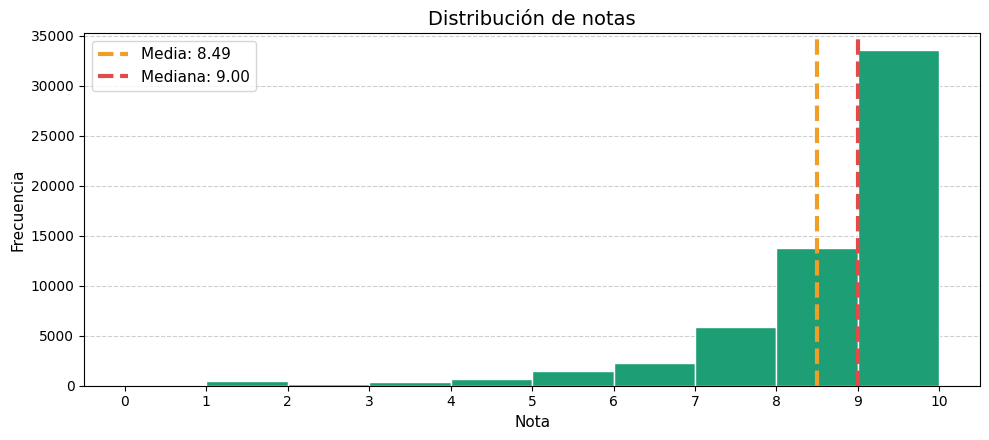

In [36]:
print("=== DISTRIBUCIÓN DE NOTAS ===")
print(df_comentarios["nota"].value_counts(normalize=True).sort_index().round(4))
print(f"\nMedia:   {df_comentarios['nota'].mean():.2f}")
print(f"Mediana: {df_comentarios['nota'].median():.2f}")
print(f"Std:     {df_comentarios['nota'].std():.2f}")

# # Histograma
# fig, ax = plt.subplots(figsize=(10, 5))

# ax.hist(df_comentarios["nota"], bins=20, color="#1D9E75", edgecolor="white")
# ax.axvline(df_comentarios["nota"].mean(), color="#E24B4A", linestyle="--",
#            label=f"Media: {df_comentarios['nota'].mean():.2f}")
# ax.axvline(df_comentarios["nota"].median(), color="#EF9F27", linestyle="--",
#            label=f"Mediana: {df_comentarios['nota'].median():.2f}")
# ax.set_title("Distribución de notas")
# ax.set_xlabel("Nota")
# ax.set_ylabel("Frecuencia")
# ax.legend(fontsize=12)

# plt.tight_layout()
# plt.show()

# Histograma
fig, ax = plt.subplots(figsize=(10, 4.5))

ax.hist(df_comentarios["nota"], bins=[0,1,2,3,4,5,6,7,8,9,10], color="#1D9E75", edgecolor="white")
ax.axvline(df_comentarios["nota"].mean(), color="#EF9F27", linestyle="--", linewidth=3,
           label=f"Media: {df_comentarios['nota'].mean():.2f}")
ax.axvline(df_comentarios["nota"].median(), color="#E24B4A", linestyle="--", linewidth=3,
           label=f"Mediana: {df_comentarios['nota'].median():.2f}")
ax.set_xticks(np.linspace(0,10,11))
ax.grid(linestyle='--', color="#CECECE", axis='y')
ax.set_axisbelow(True)
ax.set_title("Distribución de notas", fontsize=14)
ax.set_xlabel("Nota", fontsize=11)
ax.set_ylabel("Frecuencia", fontsize=11)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

Podemos ver que las notas están sesgadas, no solo a través de las proporciones, sino que también en base a los estadísticos calculados.

La media es de 8.49, lo que es muy alto y la mediana en 9.00, es decir, la mitad de las reseñas tienen nota 9 o más. Además, la desviación típica es de 1.63, lo que nos indica que las notas no varían mucho, están acumuladas arriba.

=== RESEÑAS POR HOTEL ===
nombre_del_hotel
venecia plaza centro                          9877
casual vintage valencia                       7317
the river hostel                              6534
only you hotel valencia                       5337
nh valencia las ciencias                      4708
silken puerta valencia                        4412
ilunion aqua 3                                4120
sweet hotel renasa                            3991
casual del cine valencia by casual hoteles    3962
meliá valencia                                3354
hotel las arenas balneario resort             3000
barceló valencia                              2108
Name: count, dtype: int64


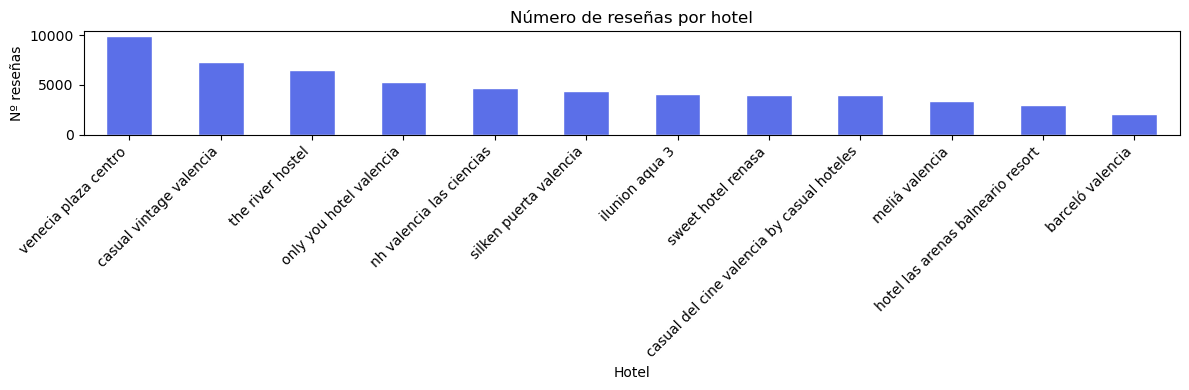

In [ ]:
# Reseñas por hotel
resenas_por_hotel = df_comentarios["nombre_del_hotel"].value_counts()
print("=== RESEÑAS POR HOTEL ===")
print(resenas_por_hotel)

resenas_por_hotel.plot(kind="bar", figsize=(12, 4), color="#5B6FE8", edgecolor="white")
plt.title("Número de reseñas por hotel")
plt.xlabel("Hotel")
plt.ylabel("Nº reseñas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

El hotel que más reseñas tiene es Venecia Plaza Centro que debe de tener tantos por a ubicación en la que está.

In [ ]:
# Longitud de los comentarios
df_comentarios["len_general"] = df_comentarios["comentario_general"].fillna("").apply(len)
df_comentarios["len_positivo"] = df_comentarios["positivo"].fillna("").apply(len)
df_comentarios["len_negativo"] = df_comentarios["negativo"].fillna("").apply(len)

print("=== LONGITUD MEDIA DE COMENTARIOS ===")
print(f"comentario_general: {df_comentarios['len_general'].mean():.0f} caracteres")
print(f"positivo:           {df_comentarios['len_positivo'].mean():.0f} caracteres")
print(f"negativo:           {df_comentarios['len_negativo'].mean():.0f} caracteres")

=== LONGITUD MEDIA DE COMENTARIOS ===
comentario_general: 18 caracteres
positivo:           59 caracteres
negativo:           45 caracteres


En general se ve que se suelen alargar más diciendo cosas positivas que negativas.

## Creación de las tres clases por el sesgo:
- Clase 0 → nota ≤ 6 (baja, ~8% del dataset)
- Clase 1 → nota 7–8 (media, ~27%)
- Clase 2 → nota 9–10 (alta, ~65%)

In [ ]:
def categorizar_nota(nota):
    if nota <= 6:   return 0   # baja
    elif nota <= 8: return 1   # media
    else:           return 2   # alta

df_comentarios["clase"] = df_comentarios["nota"].apply(categorizar_nota)

print("=== DISTRIBUCIÓN DE CLASES ===")
print(df_comentarios["clase"].value_counts(normalize=True).sort_index().round(4))

=== DISTRIBUCIÓN DE CLASES ===
clase
0    0.0930
1    0.3356
2    0.5714
Name: proportion, dtype: float64


De este análisis destaca que:

1. comentario_general tiene solo 18 caracteres de media, mientras que las columnas positivo (59) y negativo (45) tienen mucho más texto. Esto significa que para el modelo se usarán positivo y negativo como input principal, no comentario_general.
2. negativo tiene 35.396 nulos — el 60% del dataset
Tiene sentido: si alguien está contento no escribe nada en el campo negativo. Hay que rellenarlo con string vacío, no eliminarlo.
3. positivo tiene 27.493 nulos — el 47%
Mismo caso. Hay que rellenarlo también.

In [ ]:
# 1 — Rellenar nulos de texto con string vacío
# Los nulos en positivo/negativo no son errores, es que el usuario
# no escribió nada. Los rellenamos con "" para no perder la fila entera.
df_comentarios["comentario_general"] = df_comentarios["comentario_general"].fillna("")
df_comentarios["positivo"]           = df_comentarios["positivo"].fillna("")
df_comentarios["negativo"]           = df_comentarios["negativo"].fillna("")

# 2 — Eliminar notas raras (6.5 y 7.1)
# Aparecían en la distribución con proporción ~0.0000
# Son 2-3 filas con error de entrada, las eliminamos
df_comentarios = df_comentarios[~df_comentarios["nota"].isin([6.5, 7.1])]

# 3 — Crear el texto unificado para pasarle a BETO
# Concatenamos las 3 columnas de texto en una sola, le ponemos etiquetas para que el modelo sepa qué es cada parte
df_comentarios["texto_modelo"] = (
    "positivo: " + df_comentarios["positivo"] + " | " +
    "negativo: " + df_comentarios["negativo"] + " | " +
    "general: "  + df_comentarios["comentario_general"]
)